In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown as md
from epimodels.stochastic.CTMC import SIR, SIS, SIRS, SEIR
from epimodels.stochastic.CTMC.solvers import (
    GillespieSolver,
    TauLeapingSolver,
    MidpointTauLeapingSolver,
    KLeapingSolver,
)

In [2]:
model = SIR()

params = {'beta': 0.3, 'gamma': 0.1}

common_args = dict(
    inits=[990, 10, 0],
    trange=[0, 100],
    totpop=1000,
    params=params,
    reps=20,
    seed=42,
    n_points=200,
)

In [3]:
solvers = {
    "Gillespie": GillespieSolver(),
    "Tau-leaping": TauLeapingSolver(tau=0.5),
    "Midpoint Tau": MidpointTauLeapingSolver(tau=0.5),
    "K-leaping": KLeapingSolver(k=10),
}

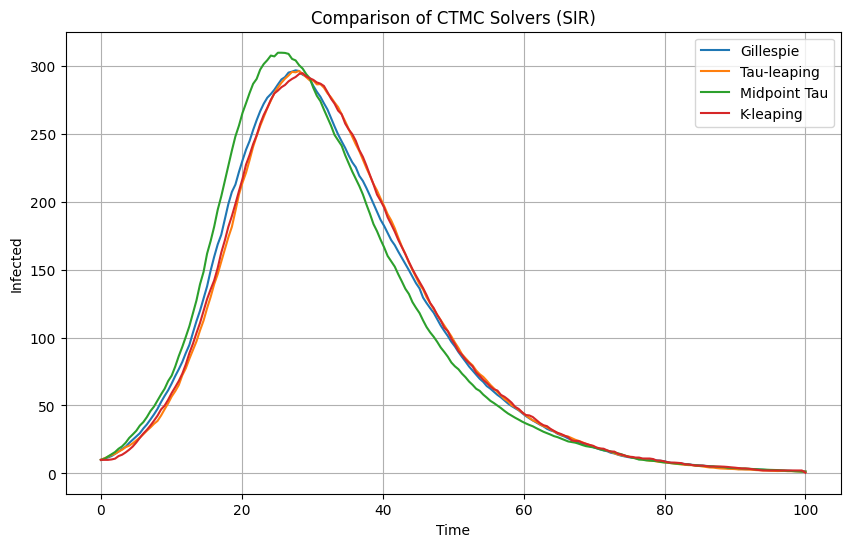

In [4]:
plt.figure(figsize=(10,6))

for name, solver in solvers.items():
    model.reset()
    model(solver=solver, **common_args)
    
    mean = model.get_mean()
    plt.plot(mean["time"], mean["I"], label=name)

plt.xlabel("Time")
plt.ylabel("Infected")
plt.title("Comparison of CTMC Solvers (SIR)")
plt.legend()
plt.grid(True)
plt.show()

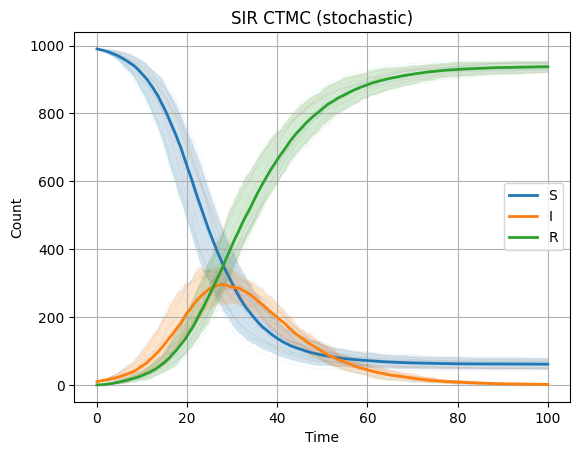

In [5]:
model.reset()
model(solver=TauLeapingSolver(tau=0.5), **common_args)

model.plot_traces(show_reps=True)